In [1]:
# =========================
# IMPORTS
# =========================
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [2]:
# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Download Dataset 

In [3]:
# =========================
# DATA PATH
# =========================
data_path = "/kaggle/working/cifar10"

# =========================
# DOWNLOAD DATA
# =========================
train_dataset_raw = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True
)

test_dataset_raw = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True
)

print("Dataset downloaded successfully")

100%|██████████| 170M/170M [00:05<00:00, 33.5MB/s] 


Dataset downloaded successfully


## Step 4: Define Standard Preprocessing

In [4]:
# =========================
# NORMALIZATION VALUES
# =========================
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

# =========================
# TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

## Step 5: Apply Preprocessing (Reusable Datasets)

In [5]:
# =========================
# DATASET WITH TRANSFORMS
# =========================
train_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=False,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=False,
    transform=test_transform
)

## Step 6: DataLoaders (Shared for All Models)

In [7]:
# =========================
# DATALOADERS
# =========================
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## Step 7: Class Labels + Sanity Check

In [8]:
# =========================
# CLASS LABELS
# =========================
classes = train_dataset.classes
print("Classes:", classes)

# =========================
# CHECK BATCH
# =========================
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])


## Vision Transformer

## Image (32×32)
## → Split into patches (e.g., 4×4)
## → Flatten each patch
## → Linear embedding
## → Add positional encoding + CLS token
## → Transformer Encoder
## → Classification head

## 🔹 Step 2: Patch Embedding

In [8]:
# =========================
# PATCH EMBEDDING
# =========================
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """
    Converts image into patches and embeds them into a vector space.
    """

    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()

        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)                  # (B, embed_dim, H', W')
        x = x.flatten(2)                 # (B, embed_dim, N)
        x = x.transpose(1, 2)            # (B, N, embed_dim)
        return x

## Step 3: Transformer Encoder Block

In [9]:
# =========================
# TRANSFORMER ENCODER BLOCK
# =========================
class TransformerEncoderBlock(nn.Module):
    """
    Single Transformer encoder block.
    """

    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Self Attention
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]

        # Feed Forward
        x = x + self.mlp(self.norm2(x))

        return x

## Step 4: Full Vision Transformer

In [10]:
# =========================
# VISION TRANSFORMER
# =========================
class VisionTransformer(nn.Module):
    """
    Vision Transformer for CIFAR-10 classification.
    """

    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=128,
        depth=6,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.1
    ):
        super().__init__()

        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.n_patches

        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Positional encoding
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        self.dropout = nn.Dropout(dropout)

        # Transformer layers
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        # Classification head
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)

        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        cls_output = x[:, 0]   # CLS token
        logits = self.head(cls_output)

        return logits

## Step 5: Initialize Model

In [11]:
# =========================
# MODEL INITIALIZATION
# =========================
model_vit = VisionTransformer().to(device)

print(model_vit)

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x TransformerEncoderBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=128, out_features=10, bias=True)
)


## Step 6: Loss + Optimizer

In [12]:
# =========================
# LOSS + OPTIMIZER
# =========================
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_vit.parameters(), lr=3e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

## Step 7: Training Loop

In [13]:
# =========================
# TRAIN FUNCTION
# =========================
def train_model(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    return total_loss / len(loader), accuracy

## Step 8: Evaluation Function

In [31]:
# =========================
# EVALUATION FUNCTION
# =========================
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100. * correct / total
    return total_loss / len(loader), accuracy, all_preds, all_labels

## Step 9: Training Execution

In [15]:
# =========================
# TRAINING LOOP
# =========================
num_epochs = 20

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_model(model_vit, train_loader)
    val_loss, val_acc, _, _ = evaluate_model(model_vit, test_loader)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}")

Epoch 1:
Train Loss: 1.7917, Train Acc: 33.03
Val Loss: 1.6097, Val Acc: 41.78
Epoch 2:
Train Loss: 1.5056, Train Acc: 44.90
Val Loss: 1.4699, Val Acc: 46.92
Epoch 3:
Train Loss: 1.3529, Train Acc: 50.83
Val Loss: 1.2194, Val Acc: 55.77
Epoch 4:
Train Loss: 1.2500, Train Acc: 54.45
Val Loss: 1.1885, Val Acc: 57.47
Epoch 5:
Train Loss: 1.1835, Train Acc: 57.36
Val Loss: 1.1460, Val Acc: 58.38
Epoch 6:
Train Loss: 1.1378, Train Acc: 58.70
Val Loss: 1.0523, Val Acc: 61.94
Epoch 7:
Train Loss: 1.0812, Train Acc: 61.13
Val Loss: 0.9990, Val Acc: 63.90
Epoch 8:
Train Loss: 1.0425, Train Acc: 62.56
Val Loss: 1.0004, Val Acc: 64.23
Epoch 9:
Train Loss: 0.9992, Train Acc: 64.08
Val Loss: 0.9348, Val Acc: 66.75
Epoch 10:
Train Loss: 0.9695, Train Acc: 65.42
Val Loss: 0.9282, Val Acc: 66.54
Epoch 11:
Train Loss: 0.8684, Train Acc: 68.99
Val Loss: 0.8310, Val Acc: 70.16
Epoch 12:
Train Loss: 0.8408, Train Acc: 69.97
Val Loss: 0.8237, Val Acc: 70.53
Epoch 13:
Train Loss: 0.8246, Train Acc: 70.45
Va

## Evaluation matrrics

In [16]:
# if needed
!pip install scikit-learn

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

## Step 4: Compute Metrics Function

In [32]:
all_preds
all_labels

[np.int64(3),
 np.int64(8),
 np.int64(8),
 np.int64(0),
 np.int64(6),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(9),
 np.int64(5),
 np.int64(7),
 np.int64(9),
 np.int64(8),
 np.int64(5),
 np.int64(7),
 np.int64(8),
 np.int64(6),
 np.int64(7),
 np.int64(0),
 np.int64(4),
 np.int64(9),
 np.int64(5),
 np.int64(2),
 np.int64(4),
 np.int64(0),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(5),
 np.int64(4),
 np.int64(5),
 np.int64(9),
 np.int64(2),
 np.int64(4),
 np.int64(1),
 np.int64(9),
 np.int64(5),
 np.int64(4),
 np.int64(6),
 np.int64(5),
 np.int64(6),
 np.int64(0),
 np.int64(9),
 np.int64(3),
 np.int64(9),
 np.int64(7),
 np.int64(6),
 np.int64(9),
 np.int64(8),
 np.int64(0),
 np.int64(3),
 np.int64(8),
 np.int64(8),
 np.int64(7),
 np.int64(7),
 np.int64(4),
 np.int64(6),
 np.int64(7),
 np.int64(3),
 np.int64(6),
 np.int64(3),
 np.int64(6),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(7),
 np.int64(2),
 np.in

In [33]:
# =========================
# METRICS FUNCTION
# =========================
def compute_metrics(all_labels, all_preds):

    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    cm = confusion_matrix(all_labels, all_preds)

    return precision, recall, f1, cm

## Run on ViT Results

In [40]:
# =========================
# GET FINAL PREDICTIONS
# =========================
val_loss, val_acc, all_preds, all_labels = evaluate_model(model_vit, test_loader)

precision, recall, f1, cm = compute_metrics(all_labels, all_preds)

print("Final Results (ViT)")
print(f"Accuracy : {val_acc:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Final Results (ViT)
Accuracy : 72.41
Precision: 0.7257
Recall   : 0.7241
F1 Score : 0.7219


## Step 6: Confusion Matrix Visualization

In [60]:
print(cm[:5])
print(cm.shape)

[[772  33  53   7  12   5   9  12  75  22]
 [ 30 815   6   6   2   5   3   5  27 101]
 [ 63   6 680  30  72  52  42  36  15   4]
 [ 30   5  81 450  45 258  57  39  23  12]
 [ 17   5 120  31 636  46  47  86  10   2]]
(10, 10)


In [61]:
import matplotlib.pyplot as plt
import numpy as np

# force backend
import matplotlib
matplotlib.use('Agg')

fig = plt.figure(figsize=(10, 8))

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - ViT")
plt.colorbar()

ticks = np.arange(len(classes))
plt.xticks(ticks, classes, rotation=45)
plt.yticks(ticks, classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# save image
plt.savefig("/kaggle/working/confusion_matrix_vit.png")

plt.close(fig)

In [62]:
import pandas as pd

df_cm = pd.DataFrame(cm, index=classes, columns=classes)
df_cm

,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
airplane,772,33,53,7,12,5,9,12,75,22
automobile,30,815,6,6,2,5,3,5,27,101
bird,63,6,680,30,72,52,42,36,15,4
cat,30,5,81,450,45,258,57,39,23,12
deer,17,5,120,31,636,46,47,86,10,2
dog,21,5,49,93,30,715,24,53,2,8
frog,13,5,77,41,31,31,780,11,8,3
horse,30,4,30,27,43,72,5,771,5,13
ship,78,27,13,9,4,3,2,1,849,14
truck,47,88,7,9,5,6,3,12,50,773


In [68]:
import matplotlib.pyplot as plt
%matplotlib inline

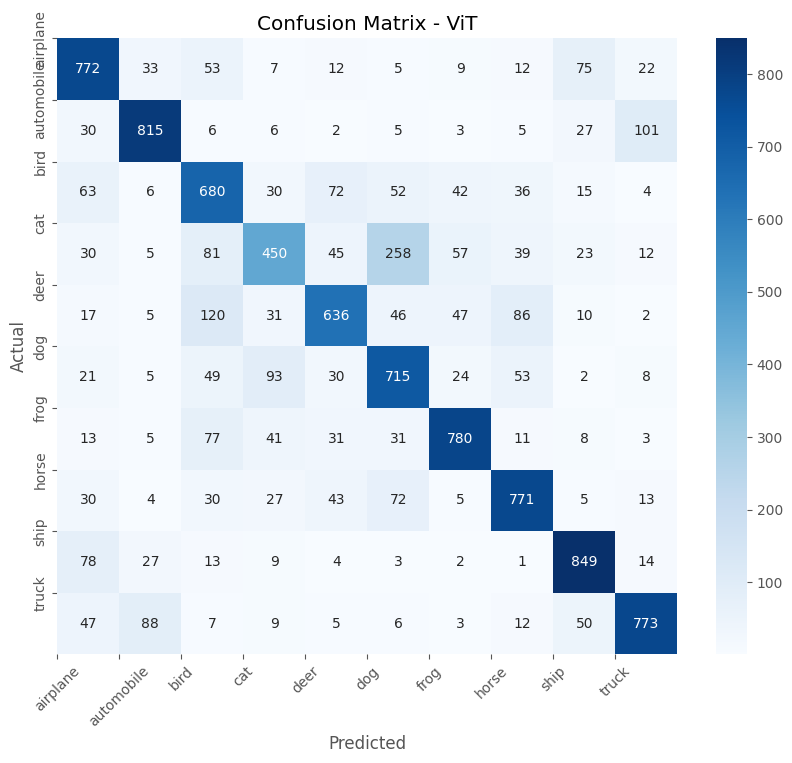

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0,        # 🔥 this removes grid lines
    linecolor=None       # extra safety
)

plt.xticks(ticks=range(len(classes)), labels=classes, rotation=45)
plt.yticks(ticks=range(len(classes)), labels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ViT")

plt.show()

##  Plot Loss Curve

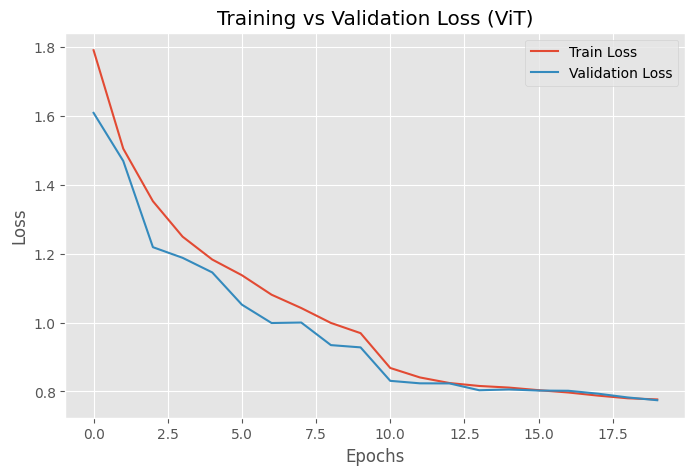

In [37]:
import matplotlib.pyplot as plt

# =========================
# LOSS CURVE
# =========================
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (ViT)")
plt.legend()

plt.show()

In [ ]:
Step 3: Plot Accuracy Curve

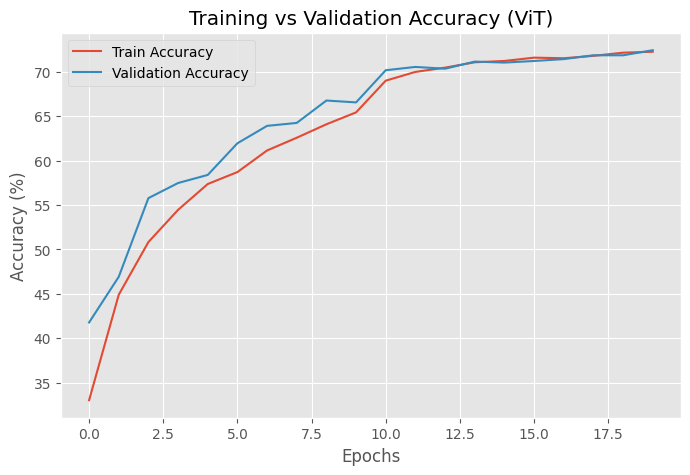

In [38]:
# =========================
# ACCURACY CURVE
# =========================
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy (ViT)")
plt.legend()

plt.show()

In [30]:
plt.style.use("ggplot")

# Next Phase: Hybrid Model (CNN + MLP)

## Step 1: Hybrid Model Architecture

In [14]:
# =========================
# HYBRID CNN + MLP MODEL
# =========================
import torch.nn as nn

class CNN_MLP(nn.Module):
    """
    Hybrid model:
    CNN for feature extraction + MLP for classification
    """

    def __init__(self, num_classes=10):
        super().__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 → 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16x16 → 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 8x8 → 4x4
        )

        # Flatten size = 128 × 4 × 4 = 2048
        self.mlp = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.mlp(x)
        return x

## Step 2: Initialize Model

In [15]:
model_hybrid = CNN_MLP().to(device)
print(model_hybrid)

CNN_MLP(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (mlp): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Step 3: Loss + Optimizer

In [16]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_hybrid.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

## Step 4: Training

In [18]:
# =========================
# TRAIN FUNCTION
# =========================
def train_model(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    return total_loss / len(loader), accuracy


# =========================
# EVALUATION FUNCTION
# =========================
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100. * correct / total
    return total_loss / len(loader), accuracy, all_preds, all_labels

In [19]:
train_model(model_hybrid, train_loader)
evaluate_model(model_hybrid, test_loader)

(1.3518557518343381,
 51.28,
 [np.int64(3),
  np.int64(8),
  np.int64(8),
  np.int64(8),
  np.int64(6),
  np.int64(6),
  np.int64(9),
  np.int64(4),
  np.int64(5),
  np.int64(1),
  np.int64(0),
  np.int64(9),
  np.int64(5),
  np.int64(9),
  np.int64(9),
  np.int64(8),
  np.int64(5),
  np.int64(9),
  np.int64(8),
  np.int64(4),
  np.int64(7),
  np.int64(0),
  np.int64(0),
  np.int64(9),
  np.int64(2),
  np.int64(4),
  np.int64(5),
  np.int64(7),
  np.int64(9),
  np.int64(6),
  np.int64(3),
  np.int64(5),
  np.int64(4),
  np.int64(3),
  np.int64(9),
  np.int64(1),
  np.int64(4),
  np.int64(9),
  np.int64(9),
  np.int64(5),
  np.int64(0),
  np.int64(6),
  np.int64(5),
  np.int64(6),
  np.int64(8),
  np.int64(9),
  np.int64(3),
  np.int64(9),
  np.int64(4),
  np.int64(4),
  np.int64(9),
  np.int64(8),
  np.int64(6),
  np.int64(3),
  np.int64(8),
  np.int64(8),
  np.int64(7),
  np.int64(3),
  np.int64(3),
  np.int64(5),
  np.int64(7),
  np.int64(5),
  np.int64(4),
  np.int64(9),
  np.int64(

In [20]:
num_epochs = 20

train_losses_h = []
val_losses_h = []
train_accs_h = []
val_accs_h = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_model(model_hybrid, train_loader)
    val_loss, val_acc, _, _ = evaluate_model(model_hybrid, test_loader)

    scheduler.step()

    train_losses_h.append(train_loss)
    val_losses_h.append(val_loss)
    train_accs_h.append(train_acc)
    val_accs_h.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}")

Epoch 1:
Train Loss: 1.3277, Train Acc: 51.57
Val Loss: 1.0978, Val Acc: 59.85
Epoch 2:
Train Loss: 1.1449, Train Acc: 58.90
Val Loss: 0.9615, Val Acc: 65.49
Epoch 3:
Train Loss: 1.0207, Train Acc: 63.89
Val Loss: 0.8737, Val Acc: 69.14
Epoch 4:
Train Loss: 0.9432, Train Acc: 66.72
Val Loss: 0.8603, Val Acc: 69.70
Epoch 5:
Train Loss: 0.8844, Train Acc: 68.79
Val Loss: 0.8070, Val Acc: 72.17
Epoch 6:
Train Loss: 0.8368, Train Acc: 70.85
Val Loss: 0.8241, Val Acc: 71.28
Epoch 7:
Train Loss: 0.7965, Train Acc: 72.13
Val Loss: 0.7299, Val Acc: 74.56
Epoch 8:
Train Loss: 0.7687, Train Acc: 73.18
Val Loss: 0.6898, Val Acc: 76.08
Epoch 9:
Train Loss: 0.7490, Train Acc: 73.86
Val Loss: 0.6536, Val Acc: 77.39
Epoch 10:
Train Loss: 0.7159, Train Acc: 75.15
Val Loss: 0.6658, Val Acc: 76.71
Epoch 11:
Train Loss: 0.6357, Train Acc: 78.00
Val Loss: 0.6021, Val Acc: 79.08
Epoch 12:
Train Loss: 0.6151, Train Acc: 78.52
Val Loss: 0.5888, Val Acc: 79.49
Epoch 13:
Train Loss: 0.6141, Train Acc: 78.73
Va

## Step 1: Get Predictions (Hybrid)

In [21]:
val_loss_h, val_acc_h, all_preds_h, all_labels_h = evaluate_model(model_hybrid, test_loader)

print("Hybrid Accuracy:", val_acc_h)

Hybrid Accuracy: 80.12


## Step 2: Compute Metrics

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def compute_metrics(all_labels, all_preds):

    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    cm = confusion_matrix(all_labels, all_preds)

    return precision, recall, f1, cm

In [24]:
precision_h, recall_h, f1_h, cm_h = compute_metrics(all_labels_h, all_preds_h)

print("Hybrid Results")
print(f"Accuracy : {val_acc_h:.2f}")
print(f"Precision: {precision_h:.4f}")
print(f"Recall   : {recall_h:.4f}")
print(f"F1 Score : {f1_h:.4f}")

Hybrid Results
Accuracy : 80.12
Precision: 0.8009
Recall   : 0.8012
F1 Score : 0.8002


Step 3: Confusion Matrix (Clean Version)

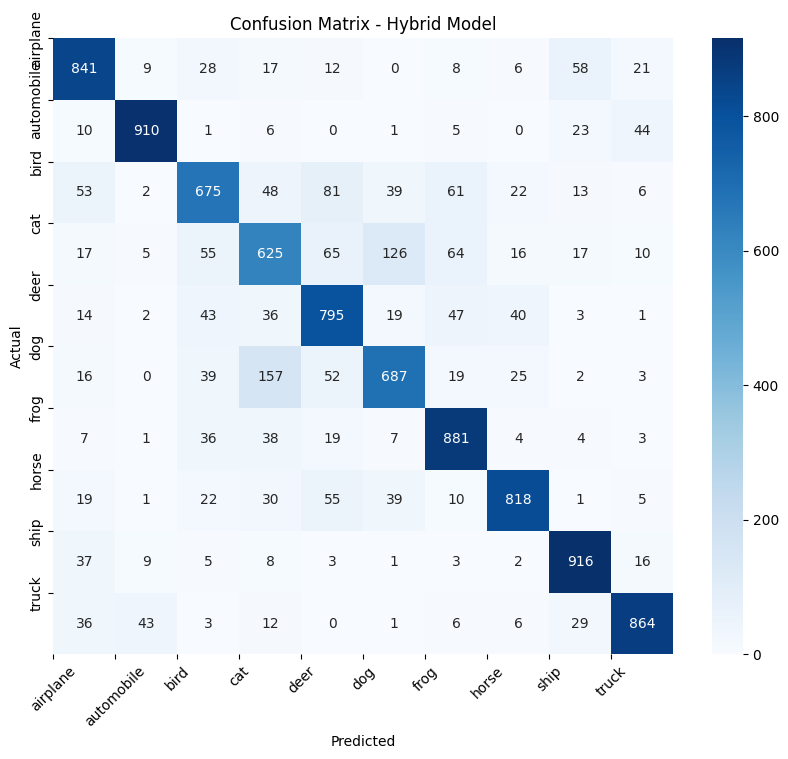

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_h,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0
)

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid Model")

plt.show()

Step 4: Training Graphs

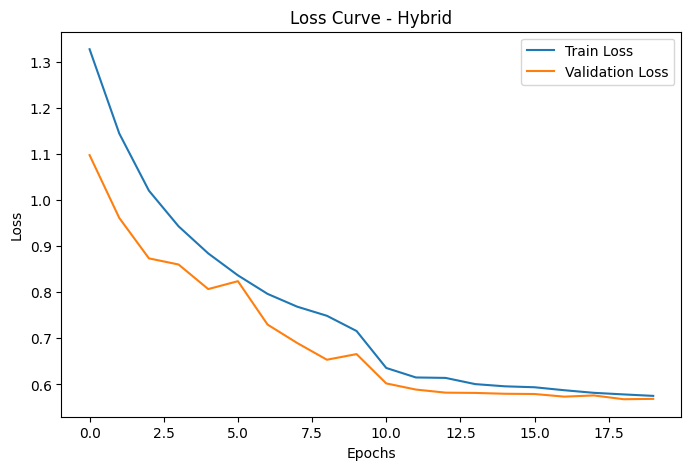

In [26]:
plt.figure(figsize=(8,5))
plt.plot(train_losses_h, label="Train Loss")
plt.plot(val_losses_h, label="Validation Loss")
plt.title("Loss Curve - Hybrid")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

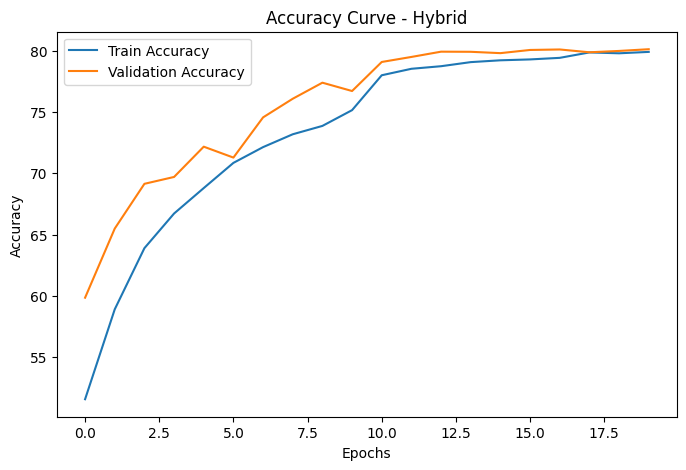

In [27]:
plt.figure(figsize=(8,5))
plt.plot(train_accs_h, label="Train Accuracy")
plt.plot(val_accs_h, label="Validation Accuracy")
plt.title("Accuracy Curve - Hybrid")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Resnet Trainig and setup

## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import DataLoader

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 3. Data Download + Correct Preprocessing (IMPORTANT)

In [3]:
# ResNet expects 224 × 224 + ImageNet normalization
# =========================
# TRANSFORMS (RESNET)
# =========================
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# DATASET
# =========================
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

# =========================
# DATALOADER
# =========================
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

classes = train_dataset.classes
print(classes)

100%|██████████| 170M/170M [00:08<00:00, 20.4MB/s] 


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 4. Load Pretrained ResNet

In [4]:
model = models.resnet18(pretrained=True)

# freeze all layers
for param in model.parameters():
    param.requires_grad = False

# unfreeze last block (important)
for param in model.layer4.parameters():
    param.requires_grad = True

# replace classifier
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


## 5. Loss + Optimizer

In [5]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

## 6. Training Function

In [7]:
def train_model(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    acc = 100 * correct / total
    return total_loss / len(loader), acc

## 7. Evaluation Function

In [8]:
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    return total_loss / len(loader), acc, all_preds, all_labels

## 8. Metrics Function

In [9]:
def compute_metrics(all_labels, all_preds):

    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    cm = confusion_matrix(all_labels, all_preds)

    return precision, recall, f1, cm

## 9. Training Loop

In [10]:
num_epochs = 20

train_losses = []
val_losses = []
train_accs = []
val_accs = []
for epoch in range(num_epochs):

    train_loss, train_acc = train_model(model, train_loader)
    val_loss, val_acc, _, _ = evaluate_model(model, test_loader)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}")

Epoch 1
Train Loss: 0.4587, Train Acc: 85.01
Val Loss: 0.3065, Val Acc: 89.61
Epoch 2
Train Loss: 0.2065, Train Acc: 93.36
Val Loss: 0.2725, Val Acc: 90.79
Epoch 3
Train Loss: 0.1220, Train Acc: 96.21
Val Loss: 0.2636, Val Acc: 91.44
Epoch 4
Train Loss: 0.0741, Train Acc: 97.86
Val Loss: 0.2668, Val Acc: 91.43
Epoch 5
Train Loss: 0.0473, Train Acc: 98.67
Val Loss: 0.2791, Val Acc: 91.14
Epoch 6
Train Loss: 0.0299, Train Acc: 99.25
Val Loss: 0.2779, Val Acc: 91.60
Epoch 7
Train Loss: 0.0206, Train Acc: 99.53
Val Loss: 0.2893, Val Acc: 91.60
Epoch 8
Train Loss: 0.0142, Train Acc: 99.67
Val Loss: 0.2939, Val Acc: 91.69
Epoch 9
Train Loss: 0.0118, Train Acc: 99.75
Val Loss: 0.3175, Val Acc: 91.44
Epoch 10
Train Loss: 0.0107, Train Acc: 99.74
Val Loss: 0.3229, Val Acc: 91.55
Epoch 11
Train Loss: 0.0062, Train Acc: 99.88
Val Loss: 0.3005, Val Acc: 92.28
Epoch 12
Train Loss: 0.0035, Train Acc: 99.97
Val Loss: 0.2985, Val Acc: 92.19
Epoch 13
Train Loss: 0.0031, Train Acc: 99.97
Val Loss: 0.297

## 10. Final Evaluation

In [11]:
val_loss, val_acc, all_preds, all_labels = evaluate_model(model, test_loader)

precision, recall, f1, cm = compute_metrics(all_labels, all_preds)

print("ResNet Final Results")
print(f"Accuracy : {val_acc:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

ResNet Final Results
Accuracy : 92.29
Precision: 0.9229
Recall   : 0.9229
F1 Score : 0.9229


## 11. Confusion Matrix (Clean)

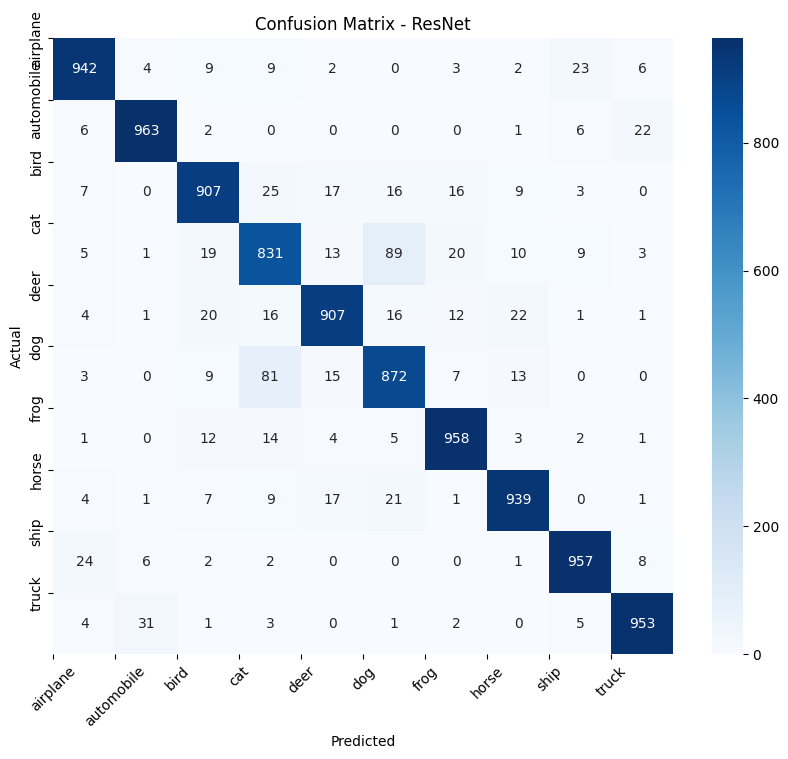

In [12]:
plt.figure(figsize=(10, 8))

sns.heatmap(## 12. Graphs
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0
)

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet")

plt.show()

## 12. Graphs

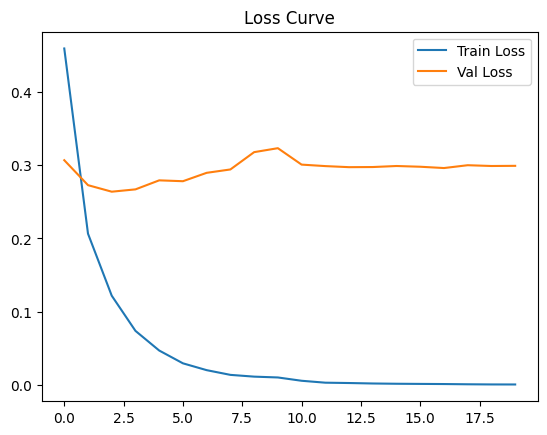

In [13]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

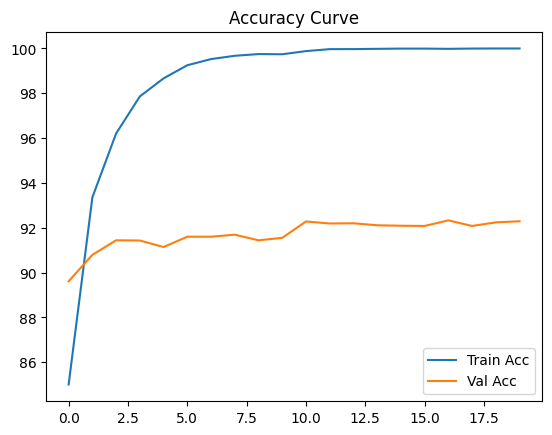

In [14]:
plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()